<a href="https://colab.research.google.com/github/Sanat1427/USL-LAB/blob/main/single_level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Merged (A-B) at distance 1.73
Merged (C-(A-B)) at distance 1.73
Merged (D-E) at distance 1.73
Merged ((C-(A-B))-(D-E)) at distance 8.77


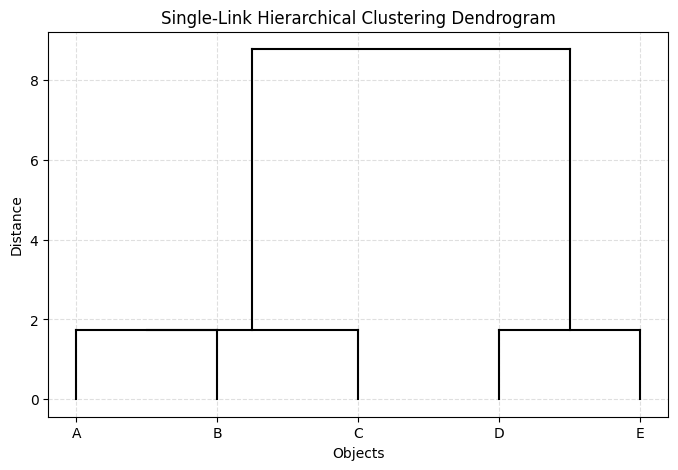

In [1]:
import numpy as np
import matplotlib.pyplot as plt


labels = ["A", "B", "C", "D", "E"]

data = np.array([
    [2, 3, 1],
    [3, 4, 2],
    [4, 5, 3],
    [10, 9, 8],
    [11, 10, 9]
])


def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def single_link_clustering(data, labels):
    n = len(data)

    # Initial clusters
    clusters = {i: [i] for i in range(n)}
    cluster_labels = {i: labels[i] for i in range(n)}

    # Precompute distance matrix
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist_matrix[i, j] = euclidean(data[i], data[j])

    history = []  # To store merge steps for dendrogram

    while len(clusters) > 1:
        min_dist = float("inf")
        pair = None

        keys = list(clusters.keys())

        # Find closest pair of clusters
        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                c1 = clusters[keys[i]]
                c2 = clusters[keys[j]]

                # Single-link distance
                d = min(dist_matrix[p][q] for p in c1 for q in c2)

                if d < min_dist:
                    min_dist = d
                    pair = (keys[i], keys[j])

        c1, c2 = pair

        # Merge clusters
        new_key = max(clusters.keys()) + 1
        new_cluster = clusters[c1] + clusters[c2]
        new_label = f"({cluster_labels[c1]}-{cluster_labels[c2]})"

        history.append((c1, c2, min_dist, len(new_cluster)))

        # Remove old clusters
        del clusters[c1]
        del clusters[c2]
        del cluster_labels[c1]
        del cluster_labels[c2]

        # Add new cluster
        clusters[new_key] = new_cluster
        cluster_labels[new_key] = new_label

        print(f"Merged {new_label} at distance {min_dist:.2f}")

    return history


merge_history = single_link_clustering(data, labels)


def plot_dendrogram(merge_history, labels):
    x_pos = {i: i for i in range(len(labels))}
    y_pos = {i: 0 for i in range(len(labels))}
    current_x = len(labels)

    plt.figure(figsize=(8, 5))

    for i, (c1, c2, dist, _) in enumerate(merge_history):
        x1, y1 = x_pos[c1], y_pos[c1]
        x2, y2 = x_pos[c2], y_pos[c2]

        x_new = (x1 + x2) / 2
        y_new = dist

        # Draw vertical lines
        plt.plot([x1, x1], [y1, y_new], 'k-')
        plt.plot([x2, x2], [y2, y_new], 'k-')

        # Draw horizontal line
        plt.plot([x1, x2], [y_new, y_new], 'k-')

        # Save new cluster position
        x_pos[len(labels) + i] = x_new
        y_pos[len(labels) + i] = y_new

    plt.xticks(range(len(labels)), labels)
    plt.title("Single-Link Hierarchical Clustering Dendrogram")
    plt.xlabel("Objects")
    plt.ylabel("Distance")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

# Plot dendrogram
plot_dendrogram(merge_history, labels)
